# Import Libraries

In [3]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import numpy as np
from PIL import Image, ImageOps
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import LabelEncoder

In [4]:
seed_value = 42

# Data Preprocessing

In [5]:
training_set = r'Dataset\Conjunctiva\train'
validation_set = r"Dataset\Conjunctiva\val"
testing_set = r"Dataset\Conjunctiva\test"

## Resizing

In [6]:
def load_and_resize(folder_path, size=(224,224)):
    images = []
    labels = []
    
    classes = os.listdir(folder_path) 
    
    for cls in classes:
        class_folder = os.path.join(folder_path, cls)
        for img_file in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_file)
            
            img = Image.open(img_path).convert('RGB')
            img = img.resize(size)
            
            img_array = np.array(img)/255.0
            
            images.append(img_array)
            labels.append(cls)
    
    return np.array(images), np.array(labels)


In [7]:
X_train, y_train = load_and_resize(training_set)
X_val, y_val = load_and_resize(validation_set)
X_test, y_test = load_and_resize(testing_set)

In [8]:
Encoder = LabelEncoder()
y_train = Encoder.fit_transform(y_train) 
y_val = Encoder.transform(y_val)
y_test = Encoder.transform(y_test)

In [9]:
print("Classes:", Encoder.classes_)
for i, cls in enumerate(Encoder.classes_):
    print(f"{i} → {cls}")

Classes: ['Anemic' 'Non-Anemic']
0 → Anemic
1 → Non-Anemic


In [10]:
print("Training set shape:", X_train.shape, y_train.shape)
print("Classes in training set:", np.unique(y_train))

Training set shape: (496, 224, 224, 3) (496,)
Classes in training set: [0 1]


In [11]:
print("Validation set shape:", X_val.shape, y_val.shape)

Validation set shape: (105, 224, 224, 3) (105,)


In [12]:
print("Testing set shape:", X_test.shape, y_test.shape)

Testing set shape: (109, 224, 224, 3) (109,)


## Rotation

In [13]:
def rotations(X, y, angles=[30, 60, 90, 120, 270]):
    rotated_images = []
    rotated_labels = []
    
    for i in range(len(X)):
        img_array = (X[i] * 255).astype(np.uint8)  
        img = Image.fromarray(img_array)
        label = y[i]
        
        rotated_images.append(np.array(img)/255.0)
        rotated_labels.append(label)
        
        for angle in angles:
            rotated = img.rotate(angle)
            rotated_images.append(np.array(rotated)/255.0)
            rotated_labels.append(label)
    
    return np.array(rotated_images), np.array(rotated_labels)


In [14]:
X_train, y_train = rotations(X_train, y_train)

In [15]:
print(X_train.shape)

(2976, 224, 224, 3)


## Horizontal and Vertical Flip

In [16]:
def flips(X, y):
    flipped_images = []
    flipped_labels = []
    
    for i in range(len(X)):
        img_array = (X[i] * 255).astype(np.uint8)  
        img = Image.fromarray(img_array)
        label = y[i]
        
        flipped_images.append(np.array(img)/255.0)
        flipped_labels.append(label)
        
        horizontal_flip = ImageOps.mirror(img)
        flipped_images.append(np.array(horizontal_flip)/255.0)
        flipped_labels.append(label)
        
        vertical_flip = ImageOps.flip(img)
        flipped_images.append(np.array(vertical_flip)/255.0)
        flipped_labels.append(label)
    
    return np.array(flipped_images), np.array(flipped_labels)


In [21]:
X_train, y_train = flips(X_train, y_train)

In [22]:
print(X_train.shape)

(8928, 224, 224, 3)


## Translation

In [23]:
Translation = ImageDataGenerator(width_shift_range=0.1,height_shift_range=0.1)

Training_Data = Translation.flow(X_train, y_train, batch_size=32, shuffle=True, seed=seed_value)


# Feature Extraction

In [18]:
input_shape = (224, 224, 3)
n_classes = 2
batch_size = 16

In [19]:
from tensorflow.keras import layers, models

In [24]:
steps_per_epoch= int((len(Training_Data))//32)
print(steps_per_epoch)

print(len(Training_Data))

8
279


# Model1 

In [32]:
model= models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, kernel_size =(3,3), activation='relu'), #32filters, relu activation
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size =(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size =(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(), #flattens to 1d array
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,394 (669.51 KB)

 Trainable params: 171,394 (669.51 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [38]:
history = model.fit(
    Training_Data,
    epochs=20,
    steps_per_epoch = steps_per_epoch,
    validation_data=(X_val, y_val)
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 549ms/step - accuracy: 0.6406 - loss: 0.6551 - val_accuracy: 0.6000 - val_loss: 0.6733
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 597ms/step - accuracy: 0.5859 - loss: 0.6799 - val_accuracy: 0.6000 - val_loss: 0.6735
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - accuracy: 0.6641 - loss: 0.6432 - val_accuracy: 0.6000 - val_loss: 0.6739
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 610ms/step - accuracy: 0.5547 - loss: 0.6960 - val_accuracy: 0.6000 - val_loss: 0.6734
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 646ms/step - accuracy: 0.6328 - loss: 0.6587 - val_accuracy: 0.6000 - val_loss: 0.6731
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 619ms/step - accuracy: 0.6406 - loss: 0.6554 - val_accuracy: 0.6000 - val_loss: 0.6734
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 658ms/step - accuracy: 0.5703 - loss: 0.6880 - val_accuracy: 0.6000 - val_loss: 0.6736
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 633ms/step - accuracy: 0.6016 - loss: 0.6726 - val_accuracy: 0.6000 - val_loss:

In [40]:
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=32)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.5963 - loss: 0.6756
Test Loss: 0.6755627989768982
Test Accuracy: 0.5963302850723267


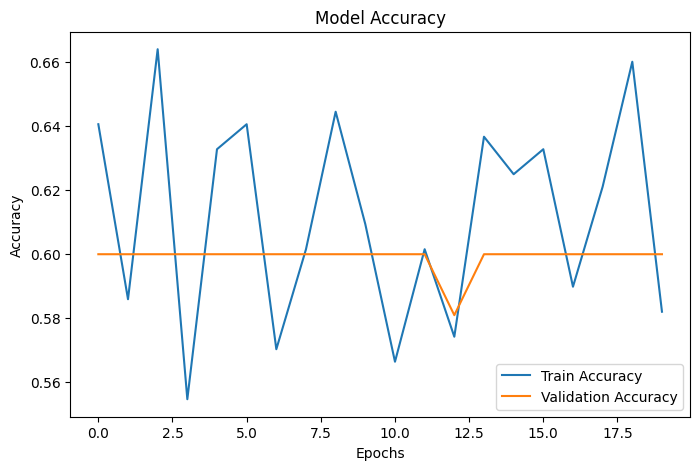

In [42]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

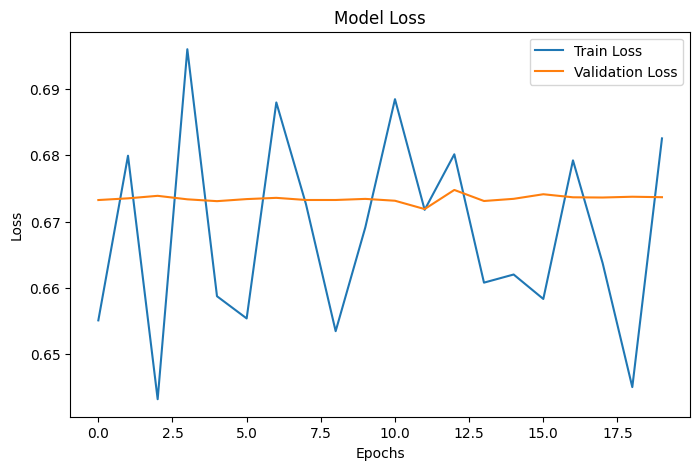

In [43]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Model 2

In [44]:
model2 = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),  
    layers.Dropout(0.5),                 
    layers.Dense(n_classes, activation='softmax')
])


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [46]:
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,282 (4.86 MB)

 Trainable params: 1,273,282 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
optimizer = Adam(learning_rate=0.0001)
model2.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [63]:
history2 = model2.fit(
    Training_Data,
    epochs=20,
    steps_per_epoch = steps_per_epoch,
    validation_data=(X_val, y_val),
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 613ms/step - accuracy: 0.6211 - loss: 0.6661 - val_accuracy: 0.6000 - val_loss: 0.6766
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 538ms/step - accuracy: 0.5977 - loss: 0.6776 - val_accuracy: 0.6000 - val_loss: 0.6755
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 542ms/step - accuracy: 0.5977 - loss: 0.6761 - val_accuracy: 0.6000 - val_loss: 0.6744
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - accuracy: 0.6250 - loss: 0.6635 - val_accuracy: 0.6000 - val_loss: 0.6737
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 564ms/step - accuracy: 0.5898 - loss: 0.6796 - val_accuracy: 0.6000 - val_loss: 0.6731
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 516ms/step - accuracy: 0.6211 - loss: 0.6647 - val_accuracy: 0.6000 - val_loss: 0.6727
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 497ms/step - accuracy: 0.6250 - loss: 0.6552 - val_accuracy: 0.6000 - val_loss: 0.6737
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 527ms/step - accuracy: 0.5508 - loss: 0.6849 - val_accuracy: 0.6000 - val_loss:

In [64]:
test_loss2, test_acc2 = model2.evaluate(X_test, y_test, batch_size=32)
print("Test Loss:", test_loss2)
print("Test Accuracy:", test_acc2)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6055 - loss: 0.6776
Test Loss: 0.6776290535926819
Test Accuracy: 0.60550457239151


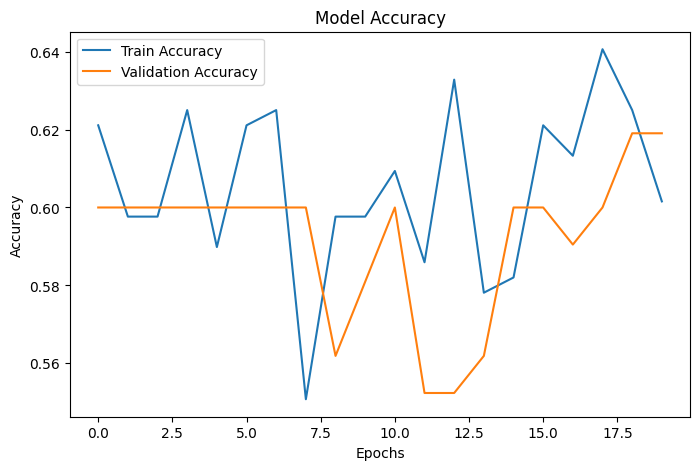

In [65]:
plt.figure(figsize=(8,5))
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

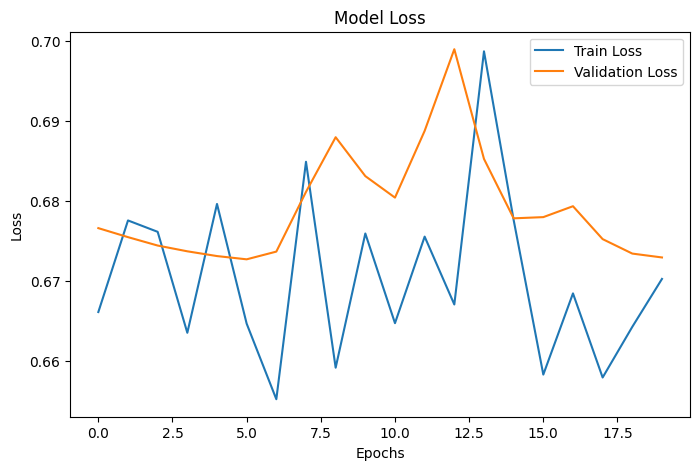

In [66]:
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Model 3

In [26]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [29]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

In [99]:
model3 = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    
    layers.Conv2D(16, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(32, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
optimizer4 = Adam(learning_rate=0.001)

In [102]:
model3.compile(
    optimizer=optimizer4,
    loss= 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [71]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

In [74]:
val_datagen = ImageDataGenerator()  # no augmentation
val_generator = val_datagen.flow(X_val, y_val, batch_size=batch_size, shuffle=False)

In [103]:
history3 = model3.fit(
    Training_Data,
    epochs=30,
    steps_per_epoch = int(len(Training_Data)),
    validation_data= (X_val,y_val),
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/30


c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


279/279 ━━━━━━━━━━━━━━━━━━━━ 207s 739ms/step - accuracy: 0.5804 - loss: 1.0411 - val_accuracy: 0.6000 - val_loss: 11.3180 - learning_rate: 0.0010
Epoch 2/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 262s 938ms/step - accuracy: 0.5966 - loss: 0.7490 - val_accuracy: 0.6190 - val_loss: 0.9514 - learning_rate: 0.0010
Epoch 3/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.5981 - loss: 0.7369 - val_accuracy: 0.6000 - val_loss: 0.7347 - learning_rate: 0.0010
Epoch 4/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.5967 - loss: 0.7335 - val_accuracy: 0.6000 - val_loss: 0.7246 - learning_rate: 0.0010
Epoch 5/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 229s 820ms/step - accuracy: 0.5962 - loss: 0.7257 - val_accuracy: 0.6000 - val_loss: 0.7187 - learning_rate: 0.0010
Epoch 6/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 347s 1s/step - accuracy: 0.5967 - loss: 0.7177 - val_accuracy: 0.6000 - val_loss: 0.7131 - learning_rate: 0.0010
Epoch 7/30
279/279 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.5962 - loss: 0.7

In [105]:
test_loss3, test_acc3 = model3.evaluate(X_test, y_test, batch_size=32)
print("Test Loss:", test_loss3)
print("Test Accuracy:", test_acc3)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.5963 - loss: 0.6751
Test Loss: 0.6750977039337158
Test Accuracy: 0.5963302850723267


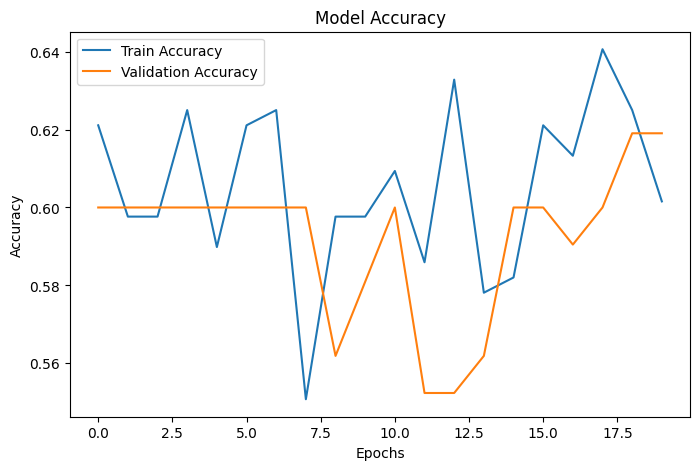

In [106]:
plt.figure(figsize=(8,5))
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

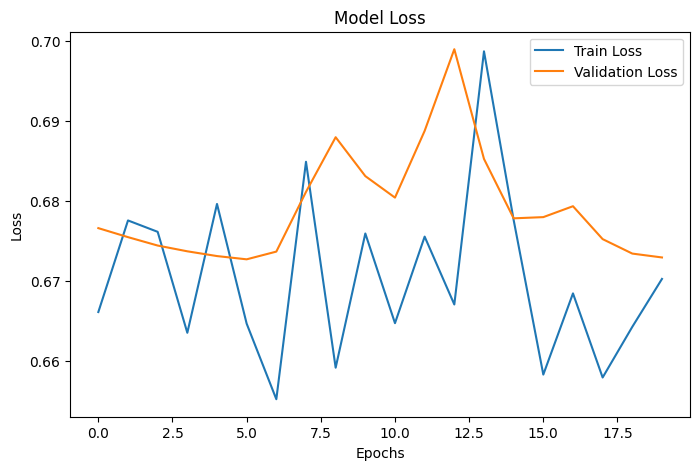

In [107]:
plt.figure(figsize=(8,5))
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MobileNetV2 - Model 3

To evaluate whether transfer learning improves conjunctiva-based anaemia classification compared to a CNN trained from scratch.

In [1]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

input_shape = (224, 224, 3)
n_classes = 2

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=input_shape,
    include_top=False,
    weights='imagenet'
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Custom classification head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(n_classes, activation='softmax')(x)

mobilenet_model = models.Model(inputs=base_model.input, outputs=output)

mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mn = mobilenet_model.fit(
    Training_Data,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val)
)


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5117 - loss: 1.0132 - val_accuracy: 0.4476 - val_loss: 0.7964
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 752ms/step - accuracy: 0.4961 - loss: 0.9891 - val_accuracy: 0.4762 - val_loss: 0.7538
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 775ms/step - accuracy: 0.5312 - loss: 0.7961 - val_accuracy: 0.6571 - val_loss: 0.7164
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 742ms/step - accuracy: 0.6055 - loss: 0.7563 - val_accuracy: 0.6571 - val_loss: 0.7023
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 802ms/step - accuracy: 0.5117 - loss: 0.8982 - val_accuracy: 0.6190 - val_loss: 0.6901
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 805ms/step - accuracy: 0.5898 - loss: 0.7639 - val_accuracy: 0.5619 - val_loss: 0.6890
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 795ms/step - accuracy: 0.5352 - loss: 0.8113 - val_accuracy: 0.6286 - val_loss: 0.6735
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 763ms/step - accuracy: 0.5938 - loss: 0.7185 - val_accuracy: 0.6476 - val_loss: 0

In [24]:
test_loss_mn, test_acc_mn = mobilenet_model.evaluate(X_test, y_test)
print("MobileNetV2 Test Accuracy:", test_acc_mn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - accuracy: 0.5872 - loss: 0.6905
MobileNetV2 Test Accuracy: 0.5871559381484985


# Self Attention Layer

In [2]:
from SelfAttention import SelfAttention
print("Imported Succesfully")

Imported Succesfully


In [27]:
model4 = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    
    layers.Conv2D(16, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(32, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    SelfAttention(),  # Your new self-attention layer!
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

model4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model4.summary()  # Check if it works!

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ self_attention_1                │ (None, 26, 26, 64)     │         5,201 │
│ (SelfAttention)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,798,323 (10.67 MB)

 Trainable params: 2,798,099 (10.67 MB)

 Non-trainable params: 224 (896.00 B)

In [30]:
history4 = model4.fit(
    Training_Data,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5312 - loss: 4.7340 - val_accuracy: 0.4000 - val_loss: 0.9764 - learning_rate: 0.0010
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 928ms/step - accuracy: 0.5273 - loss: 3.1123 - val_accuracy: 0.4000 - val_loss: 1.9270 - learning_rate: 0.0010
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 906ms/step - accuracy: 0.5898 - loss: 1.3870 - val_accuracy: 0.4000 - val_loss: 1.8774 - learning_rate: 0.0010
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.5982 - loss: 1.0396
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 887ms/step - accuracy: 0.6094 - loss: 0.9760 - val_accuracy: 0.3810 - val_loss: 1.8993 - learning_rate: 0.0010
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 868ms/step - accuracy: 0.5156 - loss: 1.0110 - val_accuracy: 0.4000 - val_loss: 2.5932 - learning_rate: 5.0000e-04
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 896ms/step - accuracy: 0.5430 - loss: 0.8260 - val_accuracy:

In [31]:
test_loss, test_acc = model4.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.3945 - loss: 0.9649
Test Accuracy: 0.39449542760849
